In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv('Real estate.csv')

In [6]:
print("Dataset first 5 record")
print(df.head())

Dataset first 5 record
   No  X1 transaction date  X2 house age  \
0   1             2012.917          32.0   
1   2             2012.917          19.5   
2   3             2013.583          13.3   
3   4             2013.500          13.3   
4   5             2012.833           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3     2

In [11]:
print("olumn names")
print(df.columns)

olumn names
Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')


In [12]:
df_cleaned = df.drop(['No', 'X1 transaction date'], axis=1)

In [13]:
print(" missing values ")
print(df_cleaned.isnull().sum())

 missing values 
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


In [15]:
X = df_cleaned.drop('Y house price of unit area', axis=1)
y = df_cleaned['Y house price of unit area']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print("data splitting : training and Testing set ready.")

data splitting : training and Testing set ready.


In [18]:
model = LinearRegression()

In [19]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
print(" model training dome ")
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

 model training dome 
Intercept: -2946.658859024454
Coefficients: [-2.70593236e-01 -4.55249601e-03  1.10512079e+00  2.36092831e+02
 -2.39036942e+01]


In [21]:
y_pred = model.predict(X_test)

In [25]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred) 

In [26]:
print(" evaluation results")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

 evaluation results
Mean Squared Error (MSE): 54.58
Root Mean Squared Error (RMSE): 7.39
R-squared Score (R2): 0.6746


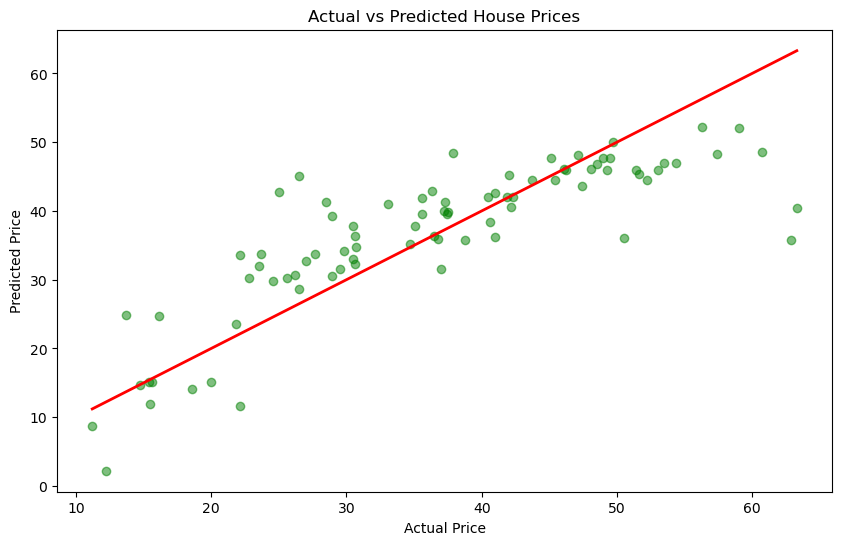

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [30]:
sample_house = [[15.0, 500.0, 5, 24.97, 121.53]] 
prediction = model.predict(sample_house)
print(f"\nSample Prediction for a 15-year old house: {prediction[0]:.2f}")


Sample Prediction for a 15-year old house: 42.75


C:\Users\Maaz\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
